# 03 Missing Values (E-09 to E-12)

**Data used:** E-09 to E-11 on the raw file without the target; E-12 on the development set.  
**Questions:** Q7 absent versus unknown, Q8 consistency, Q9 LotFrontage missingness (DOC-02 §4.3).

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import missing

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = missing.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-09_missing_values',
 'E-11_anomaly_rows',
 'E-11_consistency_checks',
 'E-12_lotfrontage_missingness',
 'E-10_missingness',
 'E-12_lotfrontage_missingness']

## E-09 Missing-value table with the absent/unknown split and planned handling.

In [3]:
outputs.tables["E-09_missing_values"]

,column,n_missing,pct_missing,n_absent,n_unknown,classification,evidence,planned_handling
0,PoolQC,2917,99.556,2917,0,absent,PoolArea == 0,Layer 1 semantic fill with 'None' (M4)
1,MiscFeature,2824,96.382,2824,0,absent,MiscVal == 0,Layer 1 semantic fill with 'None' (M4)
2,Alley,2732,93.242,2732,0,absent,data dictionary (no companion column),Layer 1 semantic fill with 'None' (M4)
3,Fence,2358,80.478,2358,0,absent,data dictionary (no companion column),Layer 1 semantic fill with 'None' (M4)
4,FireplaceQu,1422,48.532,1422,0,absent,Fireplaces == 0,Layer 1 semantic fill with 'None' (M4)
5,LotFrontage,490,16.724,0,490,unknown,genuinely unknown (DOC-02 §6.3),Layer 2 fitted imputation: median + missing in...
6,GarageCond,159,5.427,157,2,mixed,GarageArea == 0,Layer 1 semantic fill with 'None' (M4)
7,GarageFinish,159,5.427,157,2,mixed,GarageArea == 0,Layer 1 semantic fill with 'None' (M4)
8,GarageQual,159,5.427,157,2,mixed,GarageArea == 0,Layer 1 semantic fill with 'None' (M4)
9,GarageYrBlt,159,5.427,157,2,mixed,GarageArea == 0,Not imputed: replaced by HasGarage and GarageA...


## E-10 Missingness by classification.

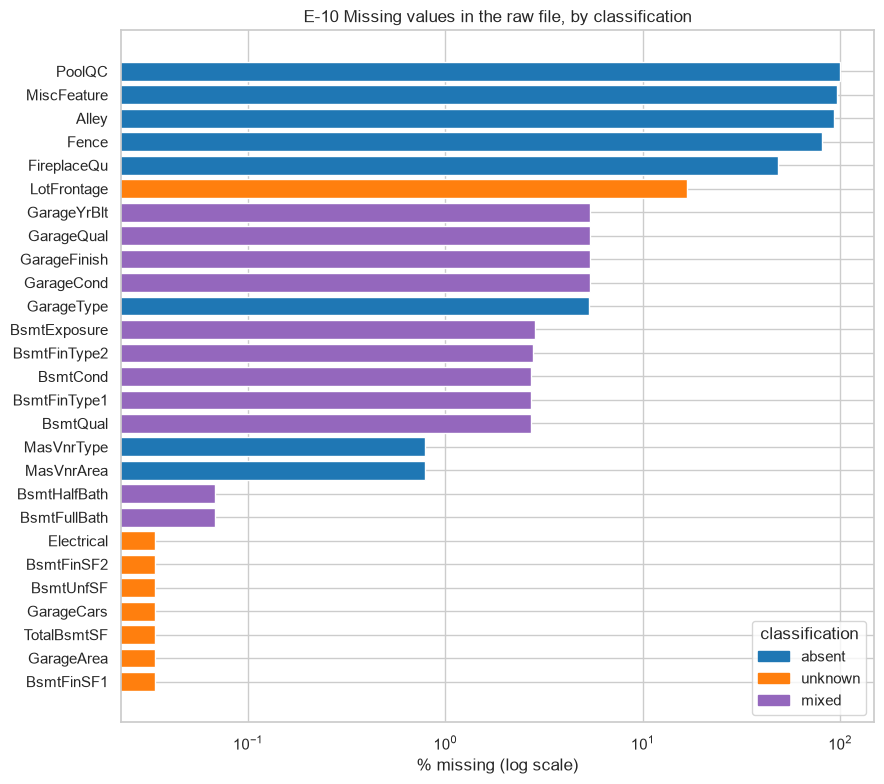

In [4]:
Image(filename=outputs.figures["E-10_missingness"])

## E-11 Consistency checks (M2 rules) and each basement/garage anomaly by `Id`.

In [5]:
outputs.tables["E-11_consistency_checks"]

,name,description,severity,status,n_rows,ids
0,garage_partially_recorded,A garage type is recorded but finish/quality/c...,warning,flagged,2,1357|2237
1,garage_absent_with_area,No garage type recorded but garage area or car...,warning,clear,0,
2,basement_exposure_missing_with_basement,Basement exists (BsmtQual recorded) but BsmtEx...,warning,flagged,3,67|1797|2780
3,basement_fintype2_missing_with_area,BsmtFinSF2 > 0 but BsmtFinType2 is missing (DO...,warning,flagged,1,445
4,basement_areas_unrecorded,Basement square-footage fields are missing (un...,warning,flagged,1,1342
5,basement_absent_with_area,All basement categoricals missing but TotalBsm...,warning,clear,0,
6,masvnr_type_area_missing_mismatch,MasVnrType and MasVnrArea are not missing toge...,warning,clear,0,
7,masvnr_none_with_area,MasVnrType is 'None' but MasVnrArea > 0.,warning,flagged,7,364|404|442|1862|1914|2004|2529
8,pool_area_without_quality,PoolArea > 0 but PoolQC is missing.,warning,clear,0,
9,electrical_unrecorded,Electrical system type is missing (genuinely u...,info,flagged,1,1578


In [6]:
outputs.tables["E-11_anomaly_rows"]

,Id,rule,related_values,interpretation
0,67,basement_exposure_missing_with_basement,BsmtQual=Gd; BsmtCond=TA; BsmtExposure=NA; Tot...,Basement exists; missing BsmtExposure is unkno...
1,445,basement_fintype2_missing_with_area,BsmtFinType1=GLQ; BsmtFinSF1=1124.0; BsmtFinTy...,Finished area exists; missing BsmtFinType2 is ...
2,1342,basement_areas_unrecorded,BsmtQual=NA; TotalBsmtSF=NA; BsmtFinSF1=NA; Bs...,Every basement field unrecorded; Layer 1 fills...
3,1357,garage_partially_recorded,GarageType=Detchd; GarageFinish=NA; GarageQual...,"Garage type recorded, other fields unknown; La..."
4,1797,basement_exposure_missing_with_basement,BsmtQual=Gd; BsmtCond=TA; BsmtExposure=NA; Tot...,Basement exists; missing BsmtExposure is unkno...
5,2237,garage_partially_recorded,GarageType=Detchd; GarageFinish=NA; GarageQual...,"Garage type recorded, other fields unknown; La..."
6,2780,basement_exposure_missing_with_basement,BsmtQual=Gd; BsmtCond=TA; BsmtExposure=NA; Tot...,Basement exists; missing BsmtExposure is unkno...


## E-12 Log price with and without `LotFrontage`.

In [7]:
outputs.tables["E-12_lotfrontage_missingness"]

,LotFrontage,n,median_log_price,mean_log_price,sd_log_price,share_pct
0,missing,382,12.057868,12.070438,0.314514,16.324786
1,recorded,1958,11.967187,12.010128,0.421816,83.675214


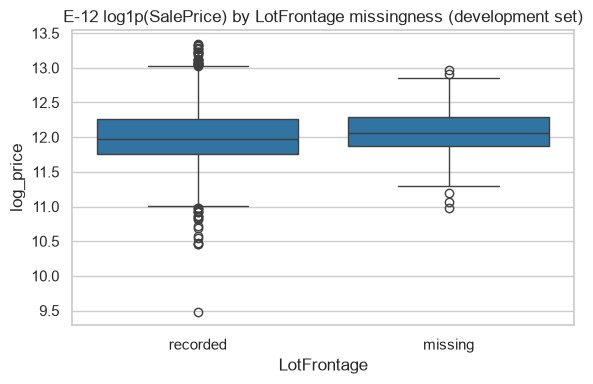

In [8]:
Image(filename=outputs.figures["E-12_lotfrontage_missingness"])